In [1]:
import numpy as np
import polars as pl
from aeon.datasets.tsc_datasets import univariate
from autotsc import utils
from aeon.visualisation import plot_critical_difference
import matplotlib.pyplot as plt
import os
from pathlib import Path

In [2]:
rdf = pl.scan_parquet("s3://tsc-glue/performance/*.parquet").collect()

/tmp/ipykernel_3931507/2919427637.py:1: UserWarning: '(default_)region' not set; polars will try to get it from bucket

Set the region manually to silence this warning.
  rdf = pl.scan_parquet("s3://tsc-glue/performance/*.parquet").collect()


In [3]:
def filter_results(rdf, resampled: bool = False):
    excluded_models = [
        'quant-catboost',
        #'mr-hydra-sgd',
        #'mr-hydra',
        'loky-stacker-v5-r1',
        'mr-hydra-baseline',
        'u-rstsf',
        #'cumsum-mr-hydra',
        'rdst',
        'stacker-v4-r1',
        'drcif',
        'hivecotev2',
        #'rank-mr-hydra',
        #'scale-mr-hydra',
        'catch22',
        'quant',
        #'downsample-mr-hydra',
        #'polar-angle-mr-hydra',
        #'difference-mr-hydra',
        #'polar-magnitude-mr-hydra',
        'rstsf'
    ]
    
    return (
        rdf
        .filter(~pl.col("model").is_in(excluded_models))
        .filter(pl.col("resampled") == resampled)
    )

df = filter_results(rdf, resampled=True)
df

dataset,model,run,resampled,test_accuracy
str,str,i64,bool,f64
"""GunPointAgeSpan""","""polar-angle-mr-hydra""",500,true,0.993671
"""PLAID""","""mr-hydra-kbest-1000""",500,true,0.910615
"""DistalPhalanxTW""","""downsample-mr-hydra""",500,true,0.57554
"""GunPointAgeSpan""","""downsample-mr-hydra""",300,true,0.914557
"""MiddlePhalanxOutlineCorrect""","""difference-mr-hydra""",300,true,0.817869
…,…,…,…,…
"""Earthquakes""","""mr-hydra-kbest-3000""",300,true,0.733813
"""CricketY""","""polar-angle-mr-hydra""",500,true,0.715385
"""FreezerSmallTrain""","""difference-mr-hydra""",400,true,0.988421


In [4]:
import seaborn as sns

/home/gasper_p/workspace/repos/AutoTSC/.venv/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 23.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/gasper_p/workspace/repos/AutoTSC/.venv/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 25.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/gasper_p/workspace/repos/AutoTSC/.venv/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 42.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/gasper_p/workspace/repos/AutoTSC/.venv/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 69.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.war

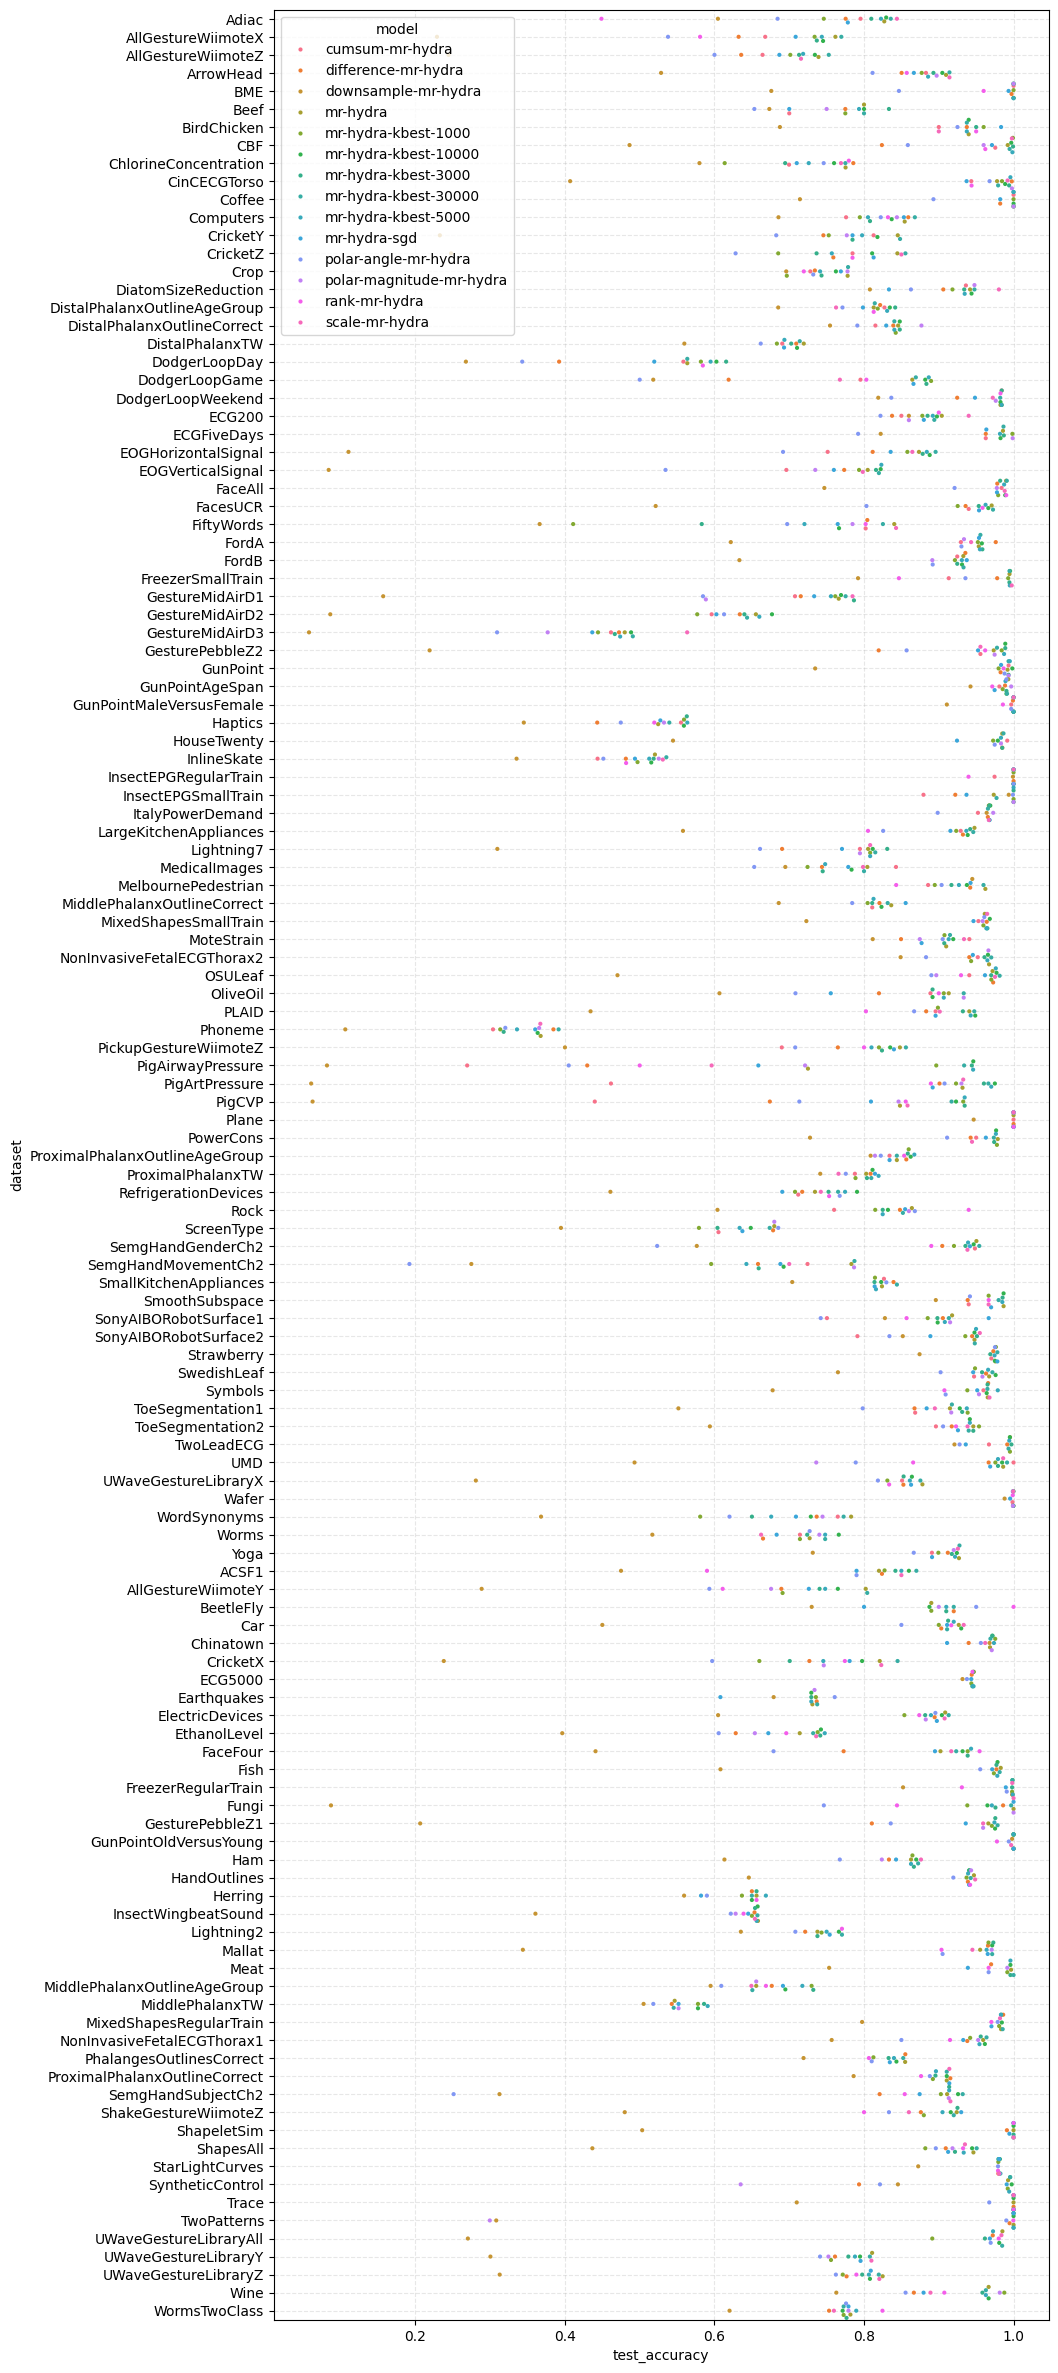

In [5]:
ax = sns.swarmplot(data=df.group_by(['dataset', 'model']).mean().sort(['model', 'dataset']), y="dataset", x="test_accuracy", hue="model", size=3)
ax.figure.set_size_inches(10, 30)
ax.grid(True, linestyle="--", alpha=0.3)

In [14]:
c = df.group_by(['dataset', 'model']).mean().sort(['model', 'dataset'])
v1 = c.filter(pl.col("model") == "mr-hydra")["test_accuracy"].to_numpy()
v2 = c.filter(pl.col("model") == "mr-hydra-kbest-30000")["test_accuracy"].to_numpy()

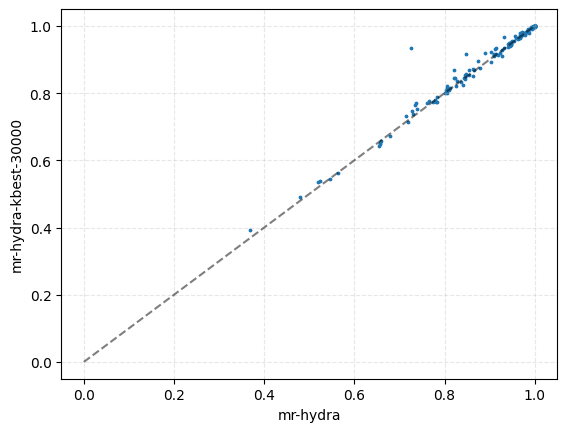

In [17]:
plt.scatter(v1, v2, s=3)
plt.xlabel("mr-hydra")
plt.ylabel("mr-hydra-kbest-30000")
plt.grid(True, linestyle="--", alpha=0.3)
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)

In [19]:
(v1<v2).mean()

np.float64(0.578125)

In [20]:
(v1>v2).mean()

np.float64(0.3359375)